# Low-cost amorphous-carbon diffusion model

Adapted from the approach in [`digital-synthesis-lab/DM2`](https://github.com/digital-synthesis-lab/DM2)
("Diffusion Models for Disordered Materials", Yang & Schwalbe-Koda 2025), which trains an
E(3)-equivariant PaiNN denoiser under a DDPM schedule to generate amorphous structures (originally SiO2).
Here the same idea is applied to **amorphous carbon**, simulated down to fit comfortably on a free-tier T4:

## 1. Setup

In [2]:
!pip -q install ase torch_geometric


In [3]:
import torch

torch_version = torch.__version__.split('+')[0]
cuda_version = "cpu" if torch.version.cuda is None else f"cu{torch.version.cuda.replace('.', '')}"
wheel_url = f"https://data.pyg.org/whl/torch-{torch_version}+{cuda_version}.html"

!pip install pyg_lib -f {wheel_url}

Looking in links: https://data.pyg.org/whl/torch-2.11.0+cu128.html


In [4]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from ase.io import read, write
from ase import Atoms
from scipy.spatial import cKDTree
from scipy.spatial.distance import pdist
from torch_geometric.nn import radius_graph
from torch_geometric.data import Data, Batch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

torch.manual_seed(0)
np.random.seed(0)


Device: cuda


## 2. Data

In [5]:
os.system('wget -q https://zenodo.org/record/3778153/files/film_10eV.xyz -O coal_trajectory.xyz')

traj = read("coal_trajectory.xyz", index=":")
print(f"Loaded {len(traj)} frames, {len(traj[-1])} atoms in the last frame.")


Loaded 1 frames, 11211 atoms in the last frame.


### Local, KD-tree-based cropping

The original draft used a single axis-aligned bounding box (`x in [10,25], y in [10,25], z in [20,35]`)
that happened to contain atoms in the *last* frame only — it is not a general recipe for cropping
arbitrary frames of a growing film. Instead, for each crop we pick a random atom in a random frame
and take its neighborhood within a fixed radius via a KD-tree. This works regardless of the frame's
size/shape and gives many *different* local environments, which is what the denoiser actually needs
to see to learn something more than one memorized point cloud.

In [6]:
CROP_RADIUS = 8.0     # Angstrom, physical radius of each local crop
SCALE = CROP_RADIUS    # length scale used to normalize coordinates into ~[-1, 1]
MIN_ATOMS, MAX_ATOMS = 100, 350
N_CROPS = 64          # lower cost: a few dozen small crops, not one huge slab

def build_crop_dataset(traj, n_crops, crop_radius, min_atoms, max_atoms, seed=0):
    rng = np.random.default_rng(seed)
    crops = []
    attempts = 0
    while len(crops) < n_crops and attempts < n_crops * 20:
        attempts += 1
        frame = traj[int(rng.integers(0, len(traj)))]
        pos = frame.get_positions()
        if len(pos) < min_atoms:
            continue
        center = pos[int(rng.integers(0, len(pos)))]
        tree = cKDTree(pos)
        idx = np.array(tree.query_ball_point(center, r=crop_radius))
        if len(idx) < min_atoms:
            continue
        if len(idx) > max_atoms:
            idx = rng.choice(idx, size=max_atoms, replace=False)
        sub_pos = pos[idx]
        sub_pos = sub_pos - sub_pos.mean(axis=0)
        crops.append(sub_pos)
    return crops

crops = build_crop_dataset(traj, N_CROPS, CROP_RADIUS, MIN_ATOMS, MAX_ATOMS)
print(f"Built {len(crops)} crops, atom counts: {[len(c) for c in crops[:10]]} ...")


Built 64 crops, atom counts: [214, 350, 214, 350, 216, 203, 218, 197, 328, 350] ...


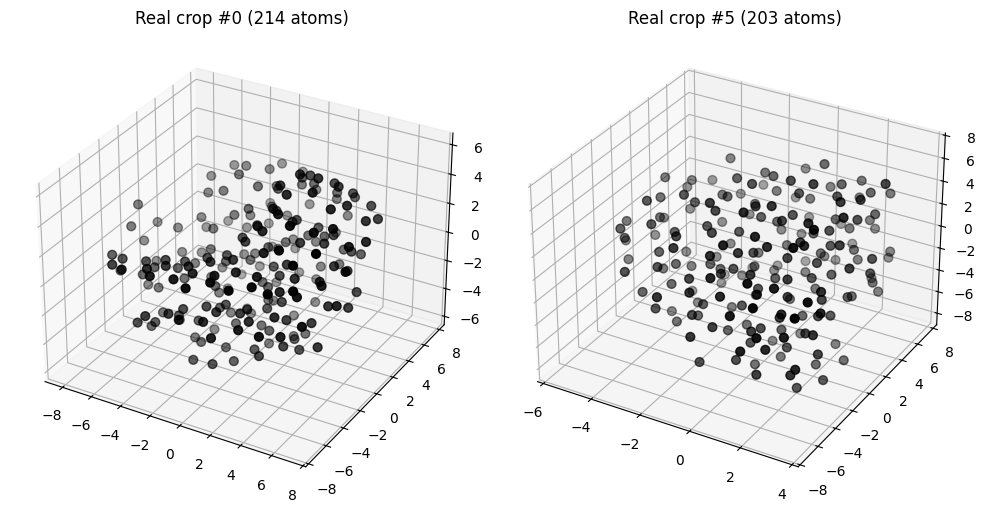

In [9]:
fig = plt.figure(figsize=(10, 5))
for i, ax_idx in enumerate([0, 5]):
    ax = fig.add_subplot(1, 2, i + 1, projection='3d')
    p = crops[ax_idx]
    ax.scatter(p[:, 0], p[:, 1], p[:, 2], c='black', s=40, depthshade=True)
    ax.set_title(f"Real crop #{ax_idx} ({len(p)} atoms)")
plt.tight_layout()
plt.show()


## 3. Model: PaiNN denoiser + DDPM schedule (scaled down)

In [10]:
class PaiNNLayer(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.msg_s_mlp = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.SiLU(), nn.Linear(hidden_dim, hidden_dim * 3))
        self.msg_r_mlp = nn.Sequential(nn.Linear(1, hidden_dim), nn.SiLU(), nn.Linear(hidden_dim, hidden_dim * 3))
        self.upd_s_mlp = nn.Sequential(nn.Linear(hidden_dim * 2, hidden_dim), nn.SiLU(), nn.Linear(hidden_dim, hidden_dim * 2))
        self.upd_v_mlp = nn.Linear(hidden_dim, hidden_dim, bias=False)

    def forward(self, s, v, pos, edge_index):
        row, col = edge_index
        r_ij = pos[col] - pos[row]
        d_ij = torch.norm(r_ij, dim=1, keepdim=True)
        dir_ij = r_ij / torch.clamp(d_ij, min=1e-4)

        s_msg = self.msg_s_mlp(s[col])
        r_msg = self.msg_r_mlp(d_ij)
        msg_val = s_msg * r_msg
        msg_split1, msg_split2, msg_split3 = torch.split(msg_val, self.hidden_dim, dim=-1)

        v_msg = v[col] * msg_split1.unsqueeze(1) + dir_ij.unsqueeze(-1) * msg_split2.unsqueeze(1)
        s_msg_out = msg_split3

        v_aggr = torch.zeros_like(v)
        v_aggr.index_add_(0, row, v_msg)
        s_aggr = torch.zeros_like(s)
        s_aggr.index_add_(0, row, s_msg_out)

        v_proj = self.upd_v_mlp(v_aggr)
        v_norm = torch.norm(v_proj, dim=1)

        s_cat = torch.cat([s + s_aggr, v_norm], dim=-1)
        s_upd = self.upd_s_mlp(s_cat)
        a_sv, a_ss = torch.split(s_upd, self.hidden_dim, dim=-1)

        dv = v_proj * a_sv.unsqueeze(1)
        ds = a_ss
        return s + ds, v + dv


class PaiNNDenoiser(nn.Module):
    # lower cost than the original 256-dim / 6-layer network
    def __init__(self, hidden_dim=128, num_layers=4):
        super().__init__()
        self.atom_embed = nn.Embedding(100, hidden_dim)
        self.time_embed = nn.Sequential(nn.Linear(1, hidden_dim), nn.SiLU(), nn.Linear(hidden_dim, hidden_dim))
        self.layers = nn.ModuleList([PaiNNLayer(hidden_dim) for _ in range(num_layers)])
        self.out_v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, z, pos, edge_index, t):
        s = self.atom_embed(z.squeeze(-1).long())
        s = s + self.time_embed(t.view(-1, 1))
        v = torch.zeros(s.size(0), 3, s.size(1), device=s.device)
        for layer in self.layers:
            s, v = layer(s, v, pos, edge_index)
        return self.out_v(v).squeeze(-1)


class DDPMScheduler:
    # fewer steps than the original (500 vs 1000) -> cheaper sampling
    def __init__(self, num_timesteps=500, beta_start=1e-4, beta_end=0.03, device='cuda'):
        self.num_timesteps = num_timesteps
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps).to(device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)

    def add_noise(self, pos, t):
        noise = torch.randn_like(pos)
        sqrt_ac = torch.sqrt(self.alphas_cumprod[t]).view(-1, 1)
        sqrt_1mac = torch.sqrt(1 - self.alphas_cumprod[t]).view(-1, 1)
        return sqrt_ac * pos + sqrt_1mac * noise, noise


In [11]:
import torch

torch_version = torch.__version__.split('+')[0]
cuda_version = "cpu" if torch.version.cuda is None else f"cu{torch.version.cuda.replace('.', '')}"
wheel_url = f"https://data.pyg.org/whl/torch-{torch_version}+{cuda_version}.html"

!pip install --force-reinstall --no-cache-dir pyg-lib torch-cluster -f {wheel_url}

Looking in links: https://data.pyg.org/whl/torch-2.11.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 97.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 81.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 309.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 311.2 MB/s eta 0:00:00
  Attempting uninstall: pyg-lib
    Found existing installation: pyg_lib 0.9.0+pt211cu128
    Uninstalling pyg_lib-0.9.0+pt211cu128:
      Successfully uninstalled pyg_lib-0.9.0+pt211cu128
  Attempting uninstall: numpy
    Found existing installation: numpy 2.5.3
    Uninstalling numpy-2.5.3:
      Successfully uninstalled numpy-2.5.3
  Attempting uninstall: scipy
    Found existing installation: scipy 1.18.1
    Uninstalling scipy-1.18.1:
      Successfully uninstalled scipy-1.18.1
  Attempting uninstall: torch-cluster
    Foun

## 4. Training



Model parameters: 4,829,184 (original draft: ~3.2M at 256-dim/6-layer)
Epoch    1 | mean loss: 1.3607
Epoch   25 | mean loss: 0.4636
Epoch   50 | mean loss: 0.4711
Epoch   75 | mean loss: 0.4480
Epoch  100 | mean loss: 0.4337
Epoch  125 | mean loss: 0.4463
Epoch  150 | mean loss: 0.4718
Epoch  175 | mean loss: 0.4471
Epoch  200 | mean loss: 0.4599
Epoch  225 | mean loss: 0.4618
Epoch  250 | mean loss: 0.4690
Epoch  275 | mean loss: 0.4877
Epoch  300 | mean loss: 0.4357
Epoch  325 | mean loss: 0.4376
Epoch  350 | mean loss: 0.4269
Epoch  375 | mean loss: 0.4483
Epoch  400 | mean loss: 0.4709
Epoch  425 | mean loss: 0.4411
Epoch  450 | mean loss: 0.4345
Epoch  475 | mean loss: 0.4235
Epoch  500 | mean loss: 0.4645
Epoch  525 | mean loss: 0.4287
Epoch  550 | mean loss: 0.4570
Epoch  575 | mean loss: 0.4622
Epoch  600 | mean loss: 0.4631
Epoch  625 | mean loss: 0.4544
Epoch  650 | mean loss: 0.4346
Epoch  675 | mean loss: 0.4268
Epoch  700 | mean loss: 0.4078
Epoch  725 | mean loss: 0.4670

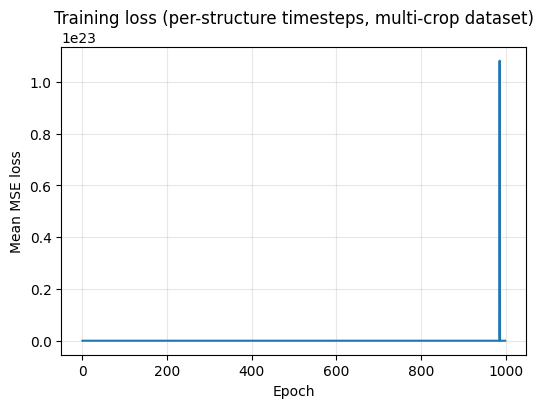

In [12]:
HIDDEN_DIM = 512
NUM_LAYERS = 6
BATCH_SIZE = 16
EPOCHS = 1000
CUTOFF_NORM = 5.0 / SCALE   # physical 5 A cutoff, normalized into crop-scale units
LR = 3e-4

data_list = [
    Data(pos=torch.tensor(c / SCALE, dtype=torch.float32),
         z=torch.full((c.shape[0], 1), 6, dtype=torch.long))
    for c in crops
]

model = PaiNNDenoiser(hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS).to(device)
scheduler = DDPMScheduler(num_timesteps=1000, device=device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,} (original draft: ~3.2M at 256-dim/6-layer)")


def train_step(batch_list):
    optimizer.zero_grad()
    batch = Batch.from_data_list(batch_list).to(device)
    pos, z, batch_idx = batch.pos, batch.z, batch.batch
    n_structs = int(batch_idx.max().item()) + 1

    t_struct = torch.randint(0, scheduler.num_timesteps, (n_structs,), device=device)
    t_atom = t_struct[batch_idx]  # one timestep per structure, broadcast to its atoms

    pos_noisy, target_noise = scheduler.add_noise(pos, t_atom)
    edge_index = radius_graph(pos_noisy, r=CUTOFF_NORM, batch=batch_idx, loop=False)

    pred_noise = model(z, pos_noisy, edge_index, t_atom.float() / scheduler.num_timesteps)
    loss = F.mse_loss(pred_noise, target_noise)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    return loss.item()


loss_history = []
rng = np.random.default_rng(1)
for epoch in range(1, EPOCHS + 1):
    order = rng.permutation(len(data_list))
    epoch_losses = []
    for start in range(0, len(order), BATCH_SIZE):
        idxs = order[start:start + BATCH_SIZE]
        batch_list = [data_list[i] for i in idxs]
        epoch_losses.append(train_step(batch_list))
    mean_loss = float(np.mean(epoch_losses))
    loss_history.append(mean_loss)
    if epoch % 25 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d} | mean loss: {mean_loss:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Mean MSE loss")
plt.title("Training loss (per-structure timesteps, multi-crop dataset)")
plt.grid(alpha=0.3)
plt.show()


## Generation (fixed signature, fp32, standard DDPM ancestral sampling)

In [13]:
@torch.no_grad()
def generate_samples(model, scheduler, num_atoms_per_sample, num_samples, device):
    model.eval()
    total = num_atoms_per_sample * num_samples
    z = torch.full((total, 1), 6, dtype=torch.long, device=device)
    batch_idx = torch.arange(num_samples, device=device).repeat_interleave(num_atoms_per_sample)
    pos = torch.randn(total, 3, device=device)

    for i in reversed(range(scheduler.num_timesteps)):
        t = torch.full((total,), i, device=device, dtype=torch.long)

        # re-center each structure independently (anti-drift)
        for s in range(num_samples):
            mask = batch_idx == s
            pos[mask] = pos[mask] - pos[mask].mean(dim=0)

        edge_index = radius_graph(pos, r=CUTOFF_NORM, batch=batch_idx, loop=False)
        pred_noise = model(z, pos, edge_index, t.float() / scheduler.num_timesteps)
        pred_noise = torch.clamp(pred_noise, -3.0, 3.0)

        alpha = scheduler.alphas[i]
        alpha_cumprod = scheduler.alphas_cumprod[i]
        beta = scheduler.betas[i]

        pos = (1 / torch.sqrt(alpha)) * (pos - ((1 - alpha) / torch.sqrt(1 - alpha_cumprod)) * pred_noise)
        if i > 0:
            pos = pos + torch.sqrt(beta) * torch.randn_like(pos)  # standard DDPM posterior noise

    pos_phys = (pos * SCALE).cpu().numpy()
    batch_np = batch_idx.cpu().numpy()
    return [pos_phys[batch_np == s] for s in range(num_samples)]


NUM_ATOMS_PER_SAMPLE = 150
NUM_SAMPLES = 5
generated = generate_samples(model, scheduler, NUM_ATOMS_PER_SAMPLE, NUM_SAMPLES, device)

for i, g in enumerate(generated):
    write(f"generated_carbon_{i}.xyz", Atoms(numbers=[6] * len(g), positions=g))
print(f"Generated and saved {NUM_SAMPLES} nanoparticles of {NUM_ATOMS_PER_SAMPLE} atoms each.")


Generated and saved 5 nanoparticles of 150 atoms each.


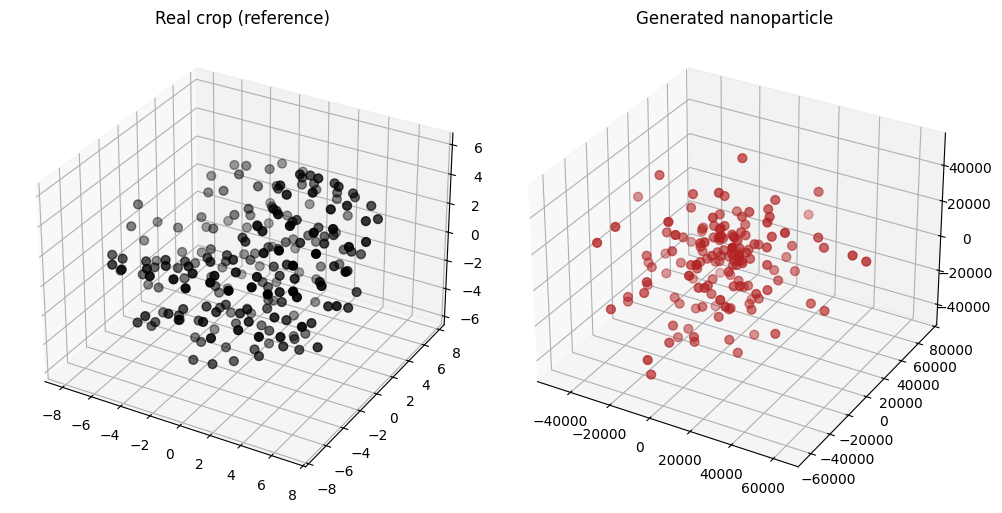

In [14]:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
p = crops[0]
ax1.scatter(p[:, 0], p[:, 1], p[:, 2], c='black', s=40, depthshade=True)
ax1.set_title("Real crop (reference)")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
g = generated[0]
ax2.scatter(g[:, 0], g[:, 1], g[:, 2], c='firebrick', s=40, depthshade=True)
ax2.set_title("Generated nanoparticle")
plt.tight_layout()
plt.show()


## Analysis

Tthe **radial
distribution** of the generated structure matches the real data — specifically whether most nearest-
neighbor distances fall in the sp2/sp3 C-C covalent bond range (1.42-1.54 A) rather than being
uniformly smeared out (which is what a model that hasn't learned real bonding statistics produces).

/usr/local/lib/python3.13/dist-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


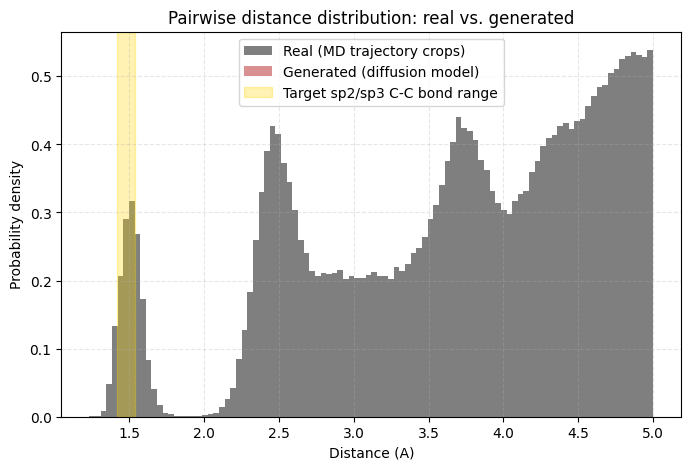

=== Quantitative structural comparison ===
Mean nearest-neighbor distance   real: 1.457 A   generated: 9379.758 A
Fraction of NN bonds in [1.42,1.54] A   real: 68.78%   generated: 0.00%
Mean coordination number (r<1.85 A)   real: 3.15   generated: 0.00


In [17]:
def pooled_pairwise_distances(structures, max_dist=5.0):
    out = []
    for s in structures:
        d = pdist(s)
        out.append(d[d < max_dist])
    return np.concatenate(out)

real_d = pooled_pairwise_distances(crops)
gen_d = pooled_pairwise_distances(generated)

plt.figure(figsize=(8, 5))
plt.hist(real_d, bins=100, density=True, alpha=0.5, color='black', label="Real (MD trajectory crops)")
plt.hist(gen_d, bins=100, density=True, alpha=0.5, color='firebrick', label="Generated (diffusion model)")
plt.axvspan(1.42, 1.54, color='gold', alpha=0.3, label="Target sp2/sp3 C-C bond range")
plt.xlabel("Distance (A)")
plt.ylabel("Probability density")
plt.title("Pairwise distance distribution: real vs. generated")
plt.legend()
plt.grid(alpha=0.3, linestyle='--')
plt.show()


def nn_distances(structures):
    out = []
    for s in structures:
        tree = cKDTree(s)
        d, _ = tree.query(s, k=2)  # k=1 is self (distance 0)
        out.append(d[:, 1])
    return np.concatenate(out)


def coordination_numbers(structures, cutoff=1.85):
    out = []
    for s in structures:
        tree = cKDTree(s)
        counts = tree.query_ball_point(s, r=cutoff, return_length=True) - 1  # exclude self
        out.append(counts)
    return np.concatenate(out)

real_nn = nn_distances(crops)
gen_nn = nn_distances(generated)
real_coord = coordination_numbers(crops)
gen_coord = coordination_numbers(generated)

frac_real_in_range = np.mean((real_nn >= 1.42) & (real_nn <= 1.54))
frac_gen_in_range = np.mean((gen_nn >= 1.42) & (gen_nn <= 1.54))

print("=== Quantitative structural comparison ===")
print(f"Mean nearest-neighbor distance   real: {real_nn.mean():.3f} A   generated: {gen_nn.mean():.3f} A")
print(f"Fraction of NN bonds in [1.42,1.54] A   real: {frac_real_in_range:.2%}   generated: {frac_gen_in_range:.2%}")
print(f"Mean coordination number (r<1.85 A)   real: {real_coord.mean():.2f}   generated: {gen_coord.mean():.2f}")


## 7. Pore analysis with Zeo++


In [16]:
atoms0 = Atoms(numbers=[6] * len(generated[0]), positions=generated[0])
atoms0.set_cell([20.0, 20.0, 20.0])
atoms0.center()
atoms0.set_pbc(True)
write('generated_carbon_0.cif', atoms0)

import subprocess
try:
    if not os.path.exists("zeo++-0.3"):
        subprocess.run(["wget", "-q", "http://www.zeoplusplus.org/zeo++-0.3.tar.gz"], check=True)
        subprocess.run(["tar", "-xf", "zeo++-0.3.tar.gz"], check=True)
    # build voro++ first, THEN zeo++ -- this ordering is the actual fix
    subprocess.run(["make"], cwd="zeo++-0.3/voro++/src", check=True)
    subprocess.run(["make"], cwd="zeo++-0.3", check=True)
    subprocess.run(["./zeo++-0.3/network", "-ha", "-sa", "1.82", "1.82", "1000",
                     "generated_carbon_0.cif"], check=True)
    with open("generated_carbon_0.sa") as f:
        print(f.read())
except Exception as e:
    print(f"Zeo++ step skipped/failed ({e}). This does not affect the diffusion model results above.")


@ generated_carbon_0.sa Unitcell_volume: 8000   Density: 0.373964   ASA_A^2: 646.632 ASA_m^2/cm^3: 808.29 ASA_m^2/g: 2161.41 NASA_A^2: 41.2611 NASA_m^2/cm^3: 51.5764 NASA_m^2/g: 137.918
Number_of_channels: 1 Channel_surface_area_A^2: 646.632  
Number_of_pockets: 11 Pocket_surface_area_A^2: 0  2.64694  7.31801  17.1273  0  9.18644  4.82677  0.155702  0  0  0  

